In [117]:
from pymongo import MongoClient
import pandas as pd
import sys

try: 
  client = MongoClient("localhost", 5001)
  print("Connected successfully!!!") 
except:
  print("Could not connect to MongoDB")

db = client
activity = client.flask_db.activity
#print("\nactivity:\n", client.flaskdb.command("dbstats"))

project_ids = (
    "656fadd102ae94a7686aae62",
    "640e22cae918523bcee8ca5e",
    "6543b8ee4180527babd20c3a",
    "656a440644dec9f71f2dee44",
    "654682f220e7d557c7e67cff",
    "6470fc81c8542274b9582aa1"
)

project_id = project_ids[5]

query = {"project": project_id, "editingLines": {"$exists": True, "$ne": None}, "revision": {"$exists": True}}


cursor = activity.find(query)

df = pd.DataFrame(list(cursor))



Connected successfully!!!


In [118]:
# hide usernames
user_arr = list(df["username"].unique())

print(user_arr)

df["author_id"] = df["username"].apply(lambda x: str(user_arr.index(x)))

df.head()

['Ritik Sachin', 'Jong Inn', 'parka438']


,_id,timestamp,text,revision,state,line,username,project,file,editingLines,...,changes,selected_text,target,suggestion,explanation,accept,start,clipboard,assistError,author_id
0,65497552f0485be5bf50b2a4,1699312978052,\section{Introduction}\n\nLarge Language Model...,"[[0, \section{Introduction}\n\nLarge Language ...",Typing,4,Ritik Sachin,6470fc81c8542274b9582aa1,1_introduction.tex,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",...,"[(4,0), Hi ---added]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,65497554f0485be5bf50b2a5,1699312980059,\section{Introduction}\n\nLarge Language Model...,"[[0, \section{Introduction}\n\nLarge Language ...",Typing,5,Ritik Sachin,6470fc81c8542274b9582aa1,1_introduction.tex,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",...,"[(5,0), \n---added]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,6549755ef0485be5bf50b2a6,1699312990246,\section{Introduction}\n\nLarge Language Model...,"[[0, \section{Introduction}\n\nLarge Language ...",Typing,4,Ritik Sachin,6470fc81c8542274b9582aa1,1_introduction.tex,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",...,"[(4,0), \n---deleted]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,6549755ff0485be5bf50b2a7,1699312991344,\section{Introduction}\n\nLarge Language Model...,"[[0, \section{Introduction}\n\nLarge Language ...",Typing,4,Ritik Sachin,6470fc81c8542274b9582aa1,1_introduction.tex,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",...,"[(4,2), ---deleted]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,65497560f0485be5bf50b2a8,1699312991693,\section{Introduction}\n\nLarge Language Model...,"[[0, \section{Introduction}\n\nLarge Language ...",Typing,4,Ritik Sachin,6470fc81c8542274b9582aa1,1_introduction.tex,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",...,"[(4,2), ---added]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [119]:
df.columns

Index(['_id', 'timestamp', 'text', 'revision', 'state', 'line', 'username',
       'project', 'file', 'editingLines', 'message', 'changes',
       'selected_text', 'target', 'suggestion', 'explanation', 'accept',
       'start', 'clipboard', 'assistError', 'author_id'],
      dtype='object')

In [120]:
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F

#Mean Pooling - Take attention mask into account for correct averaging
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output[0] #First element of model_output contains all token embeddings
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)




In [121]:
main_tex_df = df.loc[df["file"] == "main.tex"]
main_tex_df.shape

(450, 21)

In [122]:
def recreate_text(revision_arr):
    text = ""
    for diff in revision_arr:
        op, data = diff[:2]
        
        if op == 0 or op == 1:
            text += data
        elif op == 2:
            pass
            #raise Exception("illegal operations in diff")

    return text

In [123]:
df["full_text"] = df.apply(lambda x: recreate_text(x["revision"]), axis=1)
df["len"] = df["full_text"].apply(len)
df.tail(10)


,_id,timestamp,text,revision,state,line,username,project,file,editingLines,...,target,suggestion,explanation,accept,start,clipboard,assistError,author_id,full_text,len
7457,65b30e9276e561884b064c49,1706233490600,% \begin{figure}[t!]\n% \t\centering\n% \t\inc...,"[[0, % \begin{figure}[t!]\n% \t\centering\n% \...",Typing,29,Ritik Sachin,6470fc81c8542274b9582aa1,Figure_prompt.tex,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,% \begin{figure}[t!]\n% \t\centering\n% \t\inc...,2035
7458,65b30f9976e561884b064c4a,1706233752767,\usepackage[utf8]{inputenc}\n\n% This is not s...,"[[-1, % ], [0, \], [-1, b], [1, us], [0, e], [...",Paste,63,Ritik Sachin,6470fc81c8542274b9582aa1,main.tex,"[21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 3...",...,NaN,NaN,NaN,NaN,NaN,"\lstset{\n basicstyle=\ttfamily\scriptsize,...",NaN,0,\usepackage[utf8]{inputenc}\n\n% This is not s...,2892
7459,65b3104376e561884b064c4b,1706233922808,% \begin{figure}[t!]\n% \t\centering\n% \t\inc...,"[[1, % ], [0, \], [-1, us], [1, b], [0, e], [-...",Typing,12,Ritik Sachin,6470fc81c8542274b9582aa1,Figure_prompt.tex,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,% \begin{figure}[t!]\n% \t\centering\n% \t\inc...,1944
7460,65b3109976e561884b064c4c,1706234008877,% This must be in the first 5 lines to tell ar...,"[[0, % ], [-1, \], [1, This must ], [0, be], [...",Paste,63,Ritik Sachin,6470fc81c8542274b9582aa1,main.tex,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",...,NaN,NaN,NaN,NaN,NaN,"basicstyle=\ttfamily\color{black},\n moredeli...",NaN,0,% This must be in the first 5 lines to tell ar...,3173
7461,65b310d076e561884b064c4d,1706234064660,% \begin{figure}[t!]\n% \t\centering\n% \t\inc...,"[[0, % \begin{figure}[t!]\n% \t\centering\n% \...",Typing,26,Ritik Sachin,6470fc81c8542274b9582aa1,Figure_prompt.tex,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,% \begin{figure}[t!]\n% \t\centering\n% \t\inc...,1706
7462,65b310d476e561884b064c4e,1706234068363,% \begin{figure}[t!]\n% \t\centering\n% \t\inc...,"[[0, % \begin{figure}[t!]\n% \t\centering\n% \...",Typing,24,Ritik Sachin,6470fc81c8542274b9582aa1,Figure_prompt.tex,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,% \begin{figure}[t!]\n% \t\centering\n% \t\inc...,1708
7463,65b310d676e561884b064c4f,1706234070604,% \begin{figure}[t!]\n% \t\centering\n% \t\inc...,"[[0, % \begin{figure}[t!]\n% \t\centering\n% \...",Typing,26,Ritik Sachin,6470fc81c8542274b9582aa1,Figure_prompt.tex,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,% \begin{figure}[t!]\n% \t\centering\n% \t\inc...,1709
7464,65b3124676e561884b064c50,1706234437129,% This must be in the first 5 lines to tell ar...,"[[0, % ], [-1, \], [1, This must ], [0, be], [...",Paste,52,Ritik Sachin,6470fc81c8542274b9582aa1,main.tex,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",...,NaN,NaN,NaN,NaN,NaN,\usepackage{scalefnt},NaN,0,% This must be in the first 5 lines to tell ar...,3049
7465,65ca7529888271bc086d354d,1707767081286,\n% If the title and author information does n...,"[[0, \n% If the title and author information d...",Copy,92,parka438,6470fc81c8542274b9582aa1,main.tex,"[83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 9...",...,NaN,NaN,NaN,NaN,NaN,"[(147,0), \iffalse]",NaN,2,\n% If the title and author information does n...,6202
7466,65ca752a888271bc086d354e,1707767081128,\n% If the title and author information does n...,"[[-1, \], [1, \n% If the title and author info...",UndoRedo,105,parka438,6470fc81c8542274b9582aa1,main.tex,"[83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 9...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,\n% If the title and author information does n...,5453


In [124]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('paraphrase-MiniLM-L6-v2')

def get_embedding(text):        
    paragraph_embeddings = model.encode(text)

    #print(paragraph_embeddings)

    return paragraph_embeddings


In [125]:
from sklearn.manifold import TSNE
import plotly.express as px
from tqdm import tqdm
import numpy as np

tqdm.pandas()

#main_tex_df = main_tex_df.reset_index()
def encode(sentence):
    return model.encode(sentence)

df["embeddings"] = df["full_text"].progress_apply(encode)
embeddings = np.vstack(df["embeddings"])
print(embeddings)


100%|█| 7467/7467 [02:1

[[-0.3070469   0.0512154  -0.16210088 ... -0.27621463 -0.07508894
  -0.04655509]
 [-0.3070469   0.0512154  -0.16210088 ... -0.27621463 -0.07508894
  -0.04655509]
 [-0.3070469   0.0512154  -0.16210088 ... -0.27621463 -0.07508894
  -0.04655509]
 ...
 [-0.3434776   0.18559244  0.1062798  ... -0.05628945  0.1144754
   0.0411499 ]
 [ 0.13147914  0.24548253 -0.21213669 ... -0.6587957  -0.36723298
  -0.02470416]
 [ 0.13147914  0.24548253 -0.21213669 ... -0.6587957  -0.36723298
  -0.02470416]]


In [126]:
import umap
import hdbscan
import sklearn.cluster as cluster

In [127]:
umap_embedding = umap.UMAP(n_neighbors=50, min_dist=0.1, metric='cosine').fit_transform(embeddings)

In [128]:
# Cluster the reduced embeddings using KMeans
num_clusters = 5  # You can adjust this number as needed
kmeans = cluster.KMeans(n_clusters=num_clusters)
clusters = kmeans.fit_predict(embeddings)


/home/ross/miniconda3/envs/ml39/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



In [129]:
# Create a DataFrame for plotting
out_df = pd.DataFrame(umap_embedding, columns=['x', 'y'])
out_df['state'] = df['state']
out_df['file'] = df['file']
out_df['author_id'] = df['author_id']
out_df['cluster'] = pd.Series(clusters)
out_df["cluster_id"] = out_df["cluster"].apply(str)

In [130]:
print(clusters)

print(len(clusters))
print(umap_embedding)

[4 4 4 ... 2 0 0]
7467
[[10.462917  13.118661 ]
 [10.463033  13.118449 ]
 [10.470171  13.111355 ]
 ...
 [11.284275   8.762685 ]
 [ 7.3302736 42.34103  ]
 [ 7.3410172 42.32971  ]]


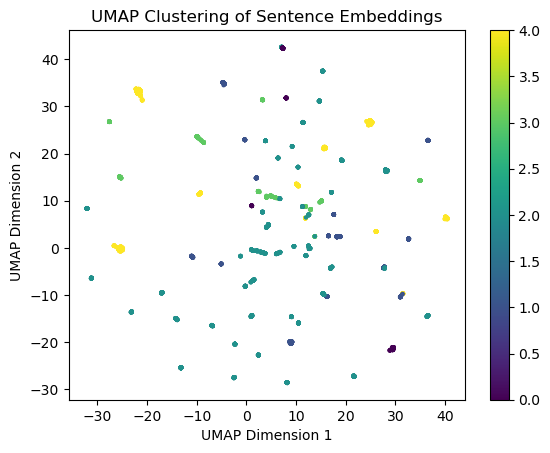

In [131]:
import matplotlib.pyplot as plt
# Visualize the clusters (optional)
plt.scatter(umap_embedding[:, 0], umap_embedding[:, 1], c=clusters, cmap='viridis', s=5)
plt.title('UMAP Clustering of Sentence Embeddings')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.colorbar()
plt.show()

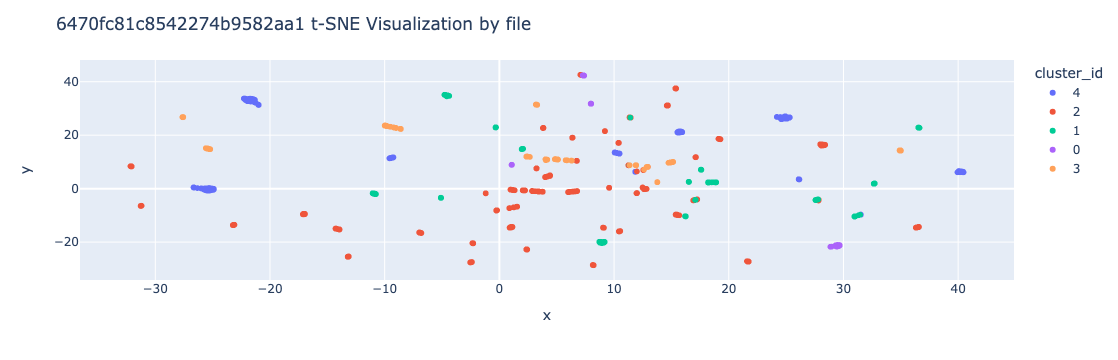

In [132]:
# Plot the embeddings using Plotly
fig = px.scatter(out_df, x='x', y='y', color='cluster_id')
fig.update_traces(textposition='top center')
fig.update_layout(title=f'{project_id} t-SNE Visualization by file',
                  xaxis_title='x',
                  yaxis_title='y',)
fig.write_image(f"figures/{project_id}_tsne_by_file.png")

fig.show()

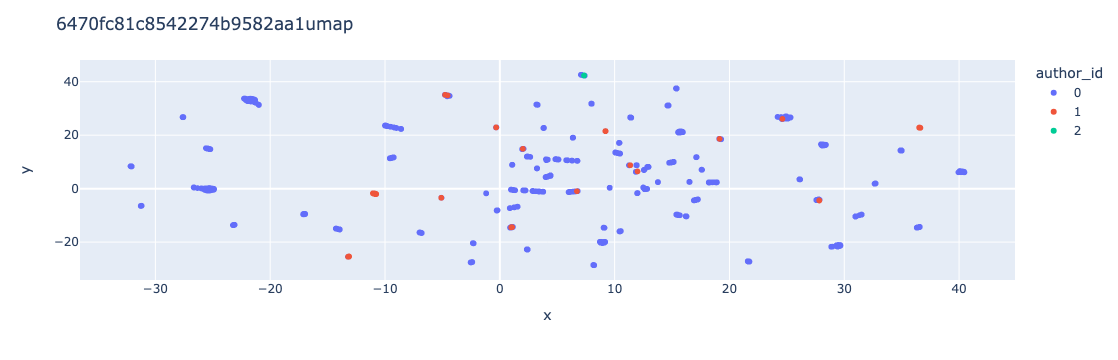

In [133]:
# Plot the embeddings using Plotly
fig = px.scatter(out_df, x='x', y='y', color='author_id')
fig.update_traces(textposition='top center')
fig.update_layout(title=f'{project_id}umap',
                  xaxis_title='x',
                  yaxis_title='y',)
fig.write_image(f"figures/{project_id}_tsne_by_file.png")

fig.show()

(2556, 384)


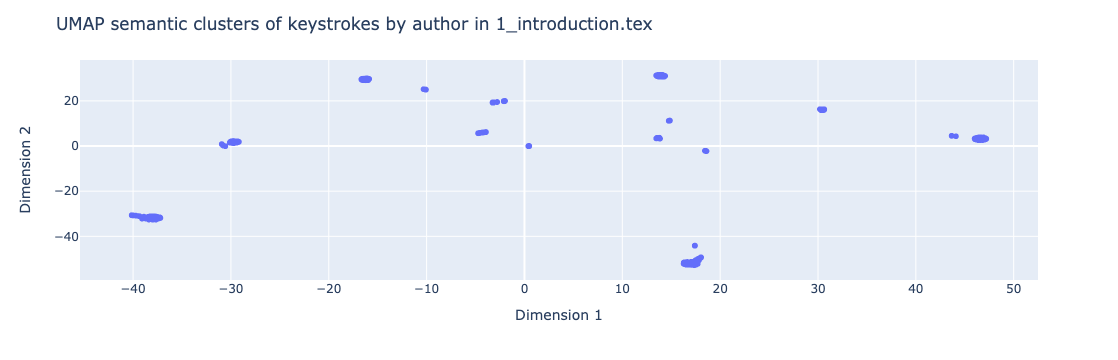

(52, 384)
(459, 384)


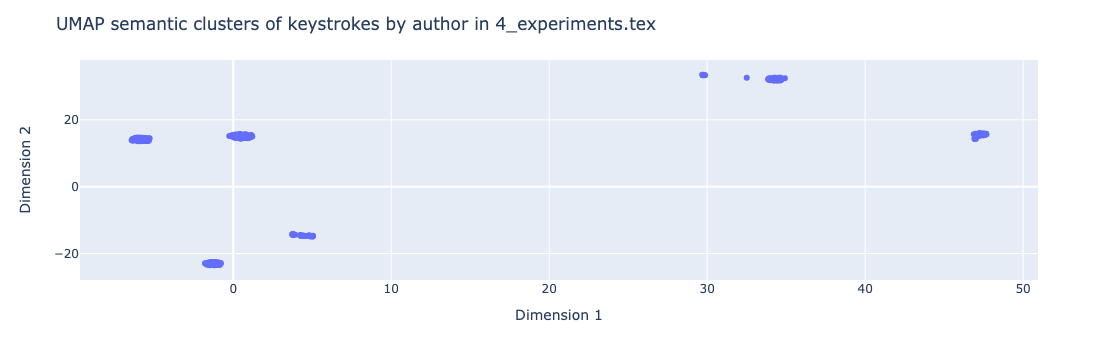

(450, 384)


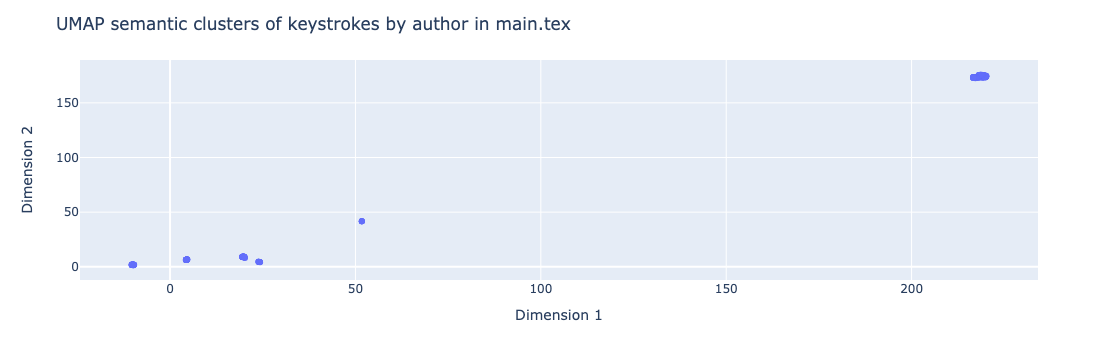

(297, 384)
(321, 384)


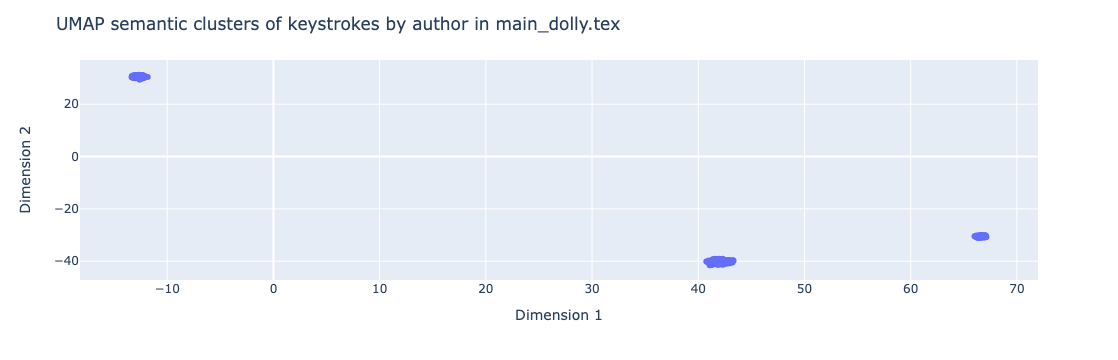

(1292, 384)


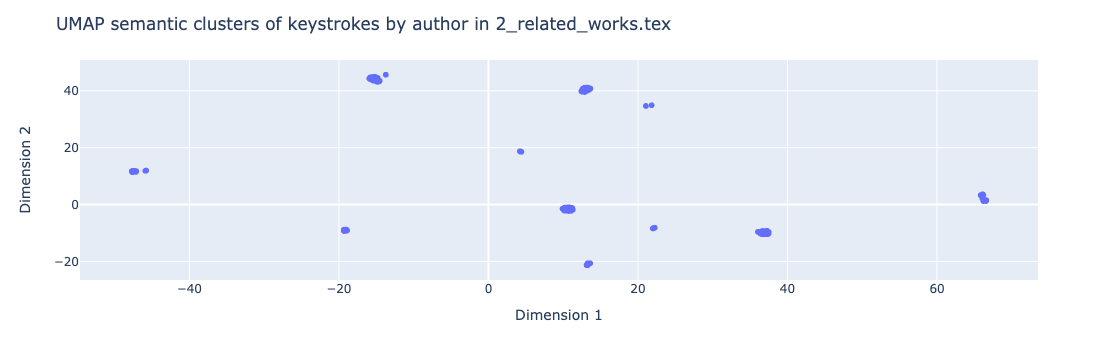

(3, 384)
(1463, 384)


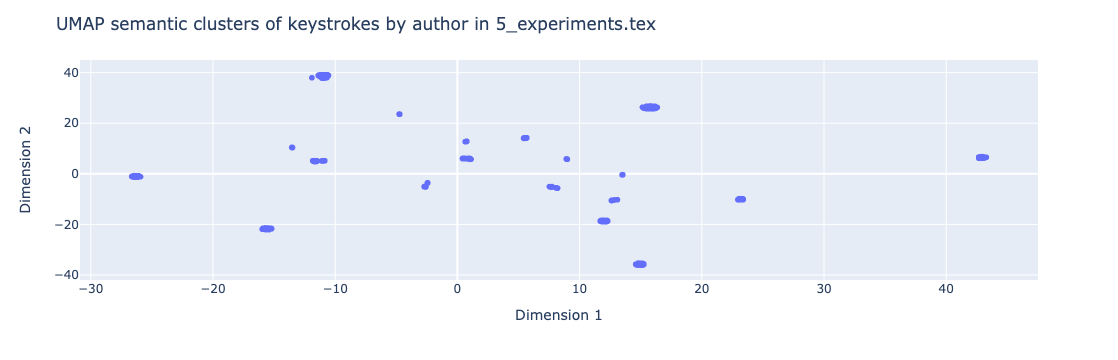

(91, 384)
(59, 384)
(3, 384)
(8, 384)
(5, 384)
(10, 384)
(1, 384)
(1, 384)
(1, 384)
(342, 384)


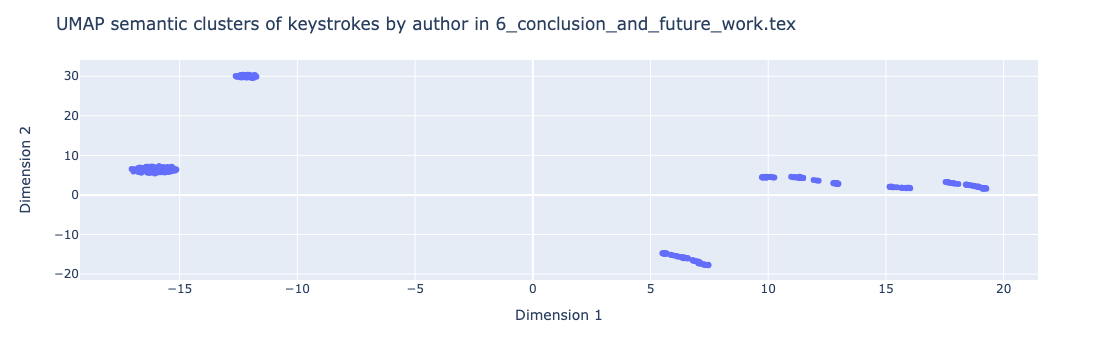

(15, 384)
(38, 384)


In [134]:
files = df["file"].unique()

#print(df.head())

for file in files:
    embeddings = np.vstack(df["embeddings"].loc[df["file"] == file])

    print(embeddings.shape)

    # files with low edit counts aren't very insighful
    if embeddings.shape[0] < 300:
        continue

    umap_embedding = umap.UMAP(n_neighbors=100, min_dist=0.1, metric='cosine').fit_transform(embeddings)

    df_plot_file = pd.DataFrame(umap_embedding, columns=['x', 'y'])
    df_plot_file['author_id'] = df['author_id']

    fig = px.scatter(df_plot_file, x='x', y='y', color='author_id')
    fig.update_traces(textposition='top center')
    fig.update_layout(title=f'UMAP semantic clusters of keystrokes by author in {file}',
                      xaxis_title='Dimension 1',
                      yaxis_title='Dimension 2',
                      showlegend=False)
    
    fig.write_image(f"figures/{project_id}_{file}_umap_by_author.png")
    fig.show()


In [135]:
print("now tsne")
raise Exception

now tsne


Exception: 

In [ ]:
# Perform t-SNE dimensionality reduction
tsne = TSNE(n_components=2, random_state=42, perplexity = 25)
embeddings_2d = tsne.fit_transform(embeddings)

In [ ]:
# Create a DataFrame for plotting
out_df = pd.DataFrame(embeddings_2d, columns=['x', 'y'])
out_df['state'] = df['state']
out_df['file'] = df['file']
out_df['author_id'] = df['author_id']

In [ ]:
# Plot the embeddings using Plotly
fig = px.scatter(out_df, x='x', y='y', color='file')
fig.update_traces(textposition='top center')
fig.update_layout(title=f'{project_id} t-SNE Visualization by file',
                  xaxis_title='x',
                  yaxis_title='y',)
fig.write_image(f"figures/{project_id}_tsne_by_file.png")

fig.show()


In [ ]:
fig = px.scatter(out_df, x='x', y='y', color='state')
fig.update_traces(textposition='top center')
fig.update_layout(title=f'{project_id} t-SNE Visualization by state',
                  xaxis_title='Dimension 1',
                  yaxis_title='Dimension 2')

fig.write_image(f"figures/{project_id}_tsne_by_state.png")
fig.show()

In [ ]:
fig = px.scatter(out_df, x='x', y='y', color='author_id')
fig.update_traces(textposition='top center')
fig.update_layout(title=f't-SNE semantic clusters of keystrokes by author in {project_id}',
                  xaxis_title='Dimension 1',
                  yaxis_title='Dimension 2',
                    showlegend=False)

fig.write_image(f"figures/{project_id}_tsne_by_author.png")
fig.show()

In [ ]:
# generate tsne for each file (main file) by username to see whether 
#people are showing similar clusters (people are writing similar sentences or file name impactso n writing behaviors)

In [ ]:
files = df["file"].unique()

#print(df.head())

for file in files:
    embeddings = np.vstack(df["embeddings"].loc[df["file"] == file])

    print(embeddings.shape)

    # files with low edit counts aren't very insighful
    if embeddings.shape[0] < 300:
        continue

    tsne = TSNE(n_components=2, random_state=42, perplexity = 25)
    embeddings_2d = tsne.fit_transform(embeddings)

    df_plot_file = pd.DataFrame(embeddings_2d, columns=['x', 'y'])
    df_plot_file['author_id'] = df['author_id']

    fig = px.scatter(df_plot_file, x='x', y='y', color='author_id')
    fig.update_traces(textposition='top center')
    fig.update_layout(title=f't-SNE semantic clusters of keystrokes by author in {file}',
                      xaxis_title='Dimension 1',
                      yaxis_title='Dimension 2',
                      showlegend=False)
    
    fig.write_image(f"figures/{project_id}_{file}_tsne_by_author.png")
    fig.show()
    

# files in each cluster table

umap by file by author like in tsne


